In [60]:
# Import necessary libraries
from urllib.parse import urlparse, parse_qs
from google_play_scraper import reviews, Sort
import pandas as pd

In [61]:
# Function to extract package name from Google Play URL
def get_package_name(play_store_url):
    parsed_url = urlparse(play_store_url)
    query_params = parse_qs(parsed_url.query)
    return query_params.get('id', [None])[0]

# Define Google Play Store URL
url = "https://play.google.com/store/apps/details?id=com.panstudio.gplay.duetnightabyss.arpg.global&hl=id"

# Extract package name
package_name = get_package_name(url)
print("Extracted Package Name:", package_name)

Extracted Package Name: com.panstudio.gplay.duetnightabyss.arpg.global


In [62]:
# Fetch reviews using the extracted package name
app_reviews, _ = reviews(
    package_name,
    lang='id',   # Language: English
    country='id',  # Country: US
    count=3000,   # Fetch 200 reviews to allow filtering
    sort= Sort.NEWEST  # Get the latest reviews
)

# Convert reviews to a DataFrame
df = pd.DataFrame(app_reviews)

# Display
df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,4b012ad4-f637-4be0-82f2-f73d3222a778,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,dev ini game niat Gak si perasaan FC Mulu kena...,1,0,1.3.108.1,2026-05-08 15:23:50,None,None,1.3.108.1
1,0b86e957-b234-4c72-b894-d9d75cf00f57,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,game ampas sampah,1,0,NaN,2026-05-07 04:29:15,None,None,NaN
2,14af9849-7d79-45b5-9088-8e6c441435b8,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,semangat yaa,1,1,1.0.5.1,2026-05-03 02:50:33,None,None,1.0.5.1
3,4c4557eb-9cc6-4eeb-802a-ea781a015a44,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,worst game i ever had,1,0,NaN,2026-05-02 04:10:54,None,None,NaN
4,77aa0f5f-cc89-4cb5-ad44-4f296ea42850,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"duet night Abyss tidak menanggapi konyol, pada...",1,0,1.3.108.1,2026-04-26 07:06:39,None,None,1.3.108.1
...,...,...,...,...,...,...,...,...,...,...,...
2107,4ac5748c-6455-471e-bd83-30b255679d07,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"akhirnya yg ditunggu-tunggu, tapi belum coba h...",4,4,1.0.5.1,2025-10-26 05:24:08,None,None,1.0.5.1
2108,585ca89c-45ae-477c-b166-4923c0a3292d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,gamenya asikkkk 😍😍😍😍😍,5,1,NaN,2025-10-26 05:16:47,None,None,NaN
2109,0d1536b7-2b32-47d1-a3df-2df064763338,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,let's go,5,1,NaN,2025-10-26 05:09:48,None,None,NaN
2110,ffd6da48-8e13-4d0b-bfd0-937f10cb350c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,🔥🔥🔥,5,1,NaN,2025-10-26 05:09:41,None,None,NaN


In [63]:
# Select only the required columns: 'reviewId', 'content', and 'score'
df_filtered_columns = df[['reviewId', 'content', 'score']]

# Display the result
df_filtered_columns

,reviewId,content,score
0,4b012ad4-f637-4be0-82f2-f73d3222a778,dev ini game niat Gak si perasaan FC Mulu kena...,1
1,0b86e957-b234-4c72-b894-d9d75cf00f57,game ampas sampah,1
2,14af9849-7d79-45b5-9088-8e6c441435b8,semangat yaa,1
3,4c4557eb-9cc6-4eeb-802a-ea781a015a44,worst game i ever had,1
4,77aa0f5f-cc89-4cb5-ad44-4f296ea42850,"duet night Abyss tidak menanggapi konyol, pada...",1
...,...,...,...
2107,4ac5748c-6455-471e-bd83-30b255679d07,"akhirnya yg ditunggu-tunggu, tapi belum coba h...",4
2108,585ca89c-45ae-477c-b166-4923c0a3292d,gamenya asikkkk 😍😍😍😍😍,5
2109,0d1536b7-2b32-47d1-a3df-2df064763338,let's go,5
2110,ffd6da48-8e13-4d0b-bfd0-937f10cb350c,🔥🔥🔥,5


In [64]:

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Mengunduh resource NLTK yang dibutuhkan (hanya perlu dijalankan sekali)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Inisialisasi lemmatizer dan daftar stopwords bahasa Inggris
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Jika teks kosong atau bukan string, kembalikan string kosong
    if not isinstance(text, str):
        return ""

    # 1. Case Folding: Mengubah teks menjadi huruf kecil semua (lowercase)
    text = text.lower()

    # 2. Menghapus URL/Link (jika ada)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 3. Menghapus tanda baca dan karakter spesial
    text = re.sub(r'[^\w\s]', '', text)

    # 4. Menghapus angka (opsional, tapi berguna untuk analisis teks umum)
    text = re.sub(r'\d+', '', text)

    # 5. Tokenization & Stopwords Removal & Lemmatization
    # Memecah kalimat menjadi kata-kata, memfilter stopwords, lalu mengubah ke kata dasar
    words = text.split()
    cleaned_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    # 6. Menggabungkan kata-kata kembali menjadi satu kalimat utuh
    return ' '.join(cleaned_words)

# Menghindari peringatan SettingWithCopyWarning dari pandas
df_filtered_columns = df_filtered_columns.copy()

# Mengaplikasikan fungsi preprocessing ke kolom 'content'
df_filtered_columns['cleaned_text'] = df_filtered_columns['content'].apply(preprocess_text)

# Membuat output yang hanya berisi text asli dan cleaned text sesuai permintaan
output_df = df_filtered_columns[['content', 'cleaned_text']]

# Menampilkan 10 baris pertama dari hasilnya
output_df.head(10)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Mareko\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Mareko\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Mareko\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,content,cleaned_text
0,dev ini game niat Gak si perasaan FC Mulu kena...,dev ini game niat gak si perasaan fc mulu kena...
1,game ampas sampah,game ampas sampah
2,semangat yaa,semangat yaa
3,worst game i ever had,worst game ever
4,"duet night Abyss tidak menanggapi konyol, pada...",duet night abyss tidak menanggapi konyol padah...
5,JARINGAN nya tidak optimal donlot data aja ser...,jaringan nya tidak optimal donlot data aja ser...
6,kurang optimal,kurang optimal
7,nyesel download loading aja lamaa bgtt udh kyk...,nyesel download loading aja lamaa bgtt udh kyk...
8,bisa memperbaiki bug yang ada saja sudah bagus...,bisa memperbaiki bug yang ada saja sudah bagus...
9,Dari segi cerita ini paling bagus 😭,dari segi cerita ini paling bagus


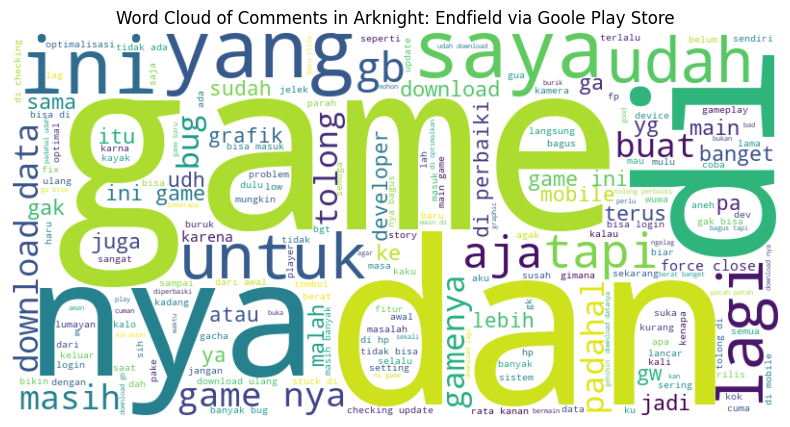

In [65]:

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all cleaned text into a single string for the word cloud
all_text = ' '.join(output_df['cleaned_text'])

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Comments in Arknight: Endfield via Goole Play Store")
plt.show()

         Word  Frequency
2        game       1268
74         di       1052
29        nya        701
47   download        680
1         ini        569
186       dan        501
56       bisa        464
39       lagi        429
92       saya        382
91     tolong        351
59       yang        350
120      udah        337
132      tapi        312
53      masih        311
32       data        306
131      main        295
58        bug        292
76      untuk        273
33        aja        259
20      tidak        254


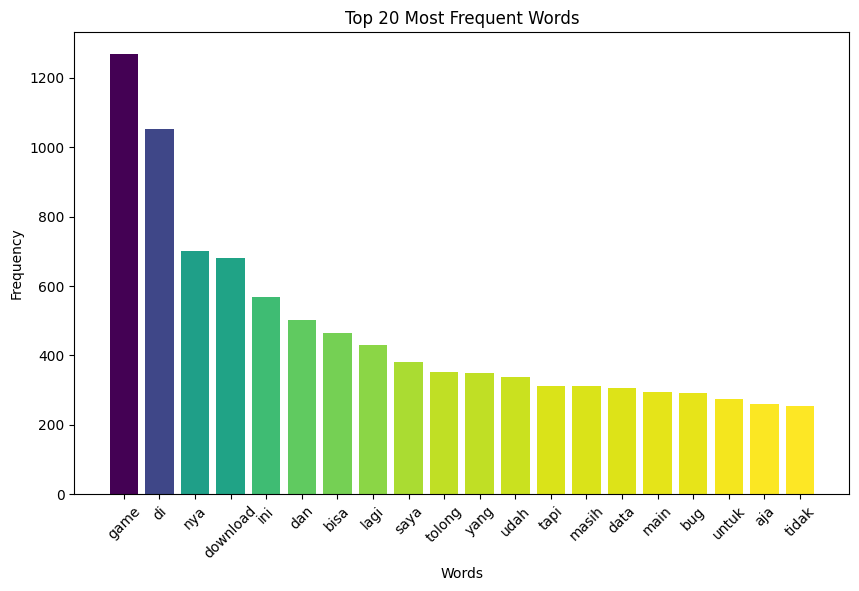

In [66]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import viridis_r
from matplotlib.colors import Normalize

# Split all cleaned text into individual words
all_words = ' '.join(output_df['cleaned_text']).split()

# Count the frequency of each word
word_counts = Counter(all_words)

# Convert the counts to a DataFrame for easier analysis
word_freq_df = pd.DataFrame(word_counts.items(), columns=['Word', 'Frequency']).sort_values(by='Frequency', ascending=False)

# Display the top 20 most frequent words
print(word_freq_df.head(20))

# Prepare inverted viridis colormap
top_words = word_freq_df.head(20)
norm = Normalize(vmin=min(top_words['Frequency']), vmax=max(top_words['Frequency']))
colors = [viridis_r(norm(value)) for value in top_words['Frequency']]

# Show a bar plot of the top 20 most frequent words with inverted viridis
plt.figure(figsize=(10, 6))
plt.bar(top_words['Word'], top_words['Frequency'], color=colors)
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 20 Most Frequent Words')
plt.xticks(rotation=45)
plt.show()

In [67]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.stem.porter import PorterStemmer

# 1. Initialize the stemmer
porter = PorterStemmer()

# 2. Define the tokenizer function
def tokenizer_porter(text):
    return [porter.stem(word) for word in text.split()]

# 3. Define TF-IDF vectorizer
tfidf = TfidfVectorizer(strip_accents=None,
                        lowercase=False,
                        tokenizer=tokenizer_porter,
                        token_pattern=None,
                        use_idf=True,
                        norm='l2',
                        smooth_idf=True)

# Fit and transform your cleaned text
tfidf_matrix = tfidf.fit_transform(output_df['cleaned_text'])
print(tfidf_matrix.shape)

(2112, 4677)


In [68]:

from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Membuat kolom label 'sentiment' berdasarkan 'score'
df_filtered_columns['sentiment'] = df_filtered_columns['score'].apply(lambda x: 1 if x > 3 else 0)

# 2. Inisialisasi TF-IDF Vectorizer (menggunakan default tokenizer)
tfidf = TfidfVectorizer(strip_accents=None,
                        lowercase=False,
                        use_idf=True,
                        norm='l2',
                        smooth_idf=True)

# 3. Transformasi teks yang sudah dibersihkan (cleaned_text) menjadi matriks fitur (X)
X = tfidf.fit_transform(df_filtered_columns['cleaned_text'])

# 4. Target variabel (Y)
y = df_filtered_columns['sentiment']

print("Dimensi fitur X:", X.shape)
print("Dimensi target y:", y.shape)

Dimensi fitur X: (2112, 4854)
Dimensi target y: (2112,)


In [69]:

from sklearn.model_selection import train_test_split

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah data training: {X_train.shape[0]}")
print(f"Jumlah data testing: {X_test.shape[0]}")

Jumlah data training: 1689
Jumlah data testing: 423


In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Inisialisasi model Logistic Regression
model = LogisticRegression()

# 2. Melatih (Training) model menggunakan data train
model.fit(X_train, y_train)

# 3. Memprediksi data test
y_pred = model.predict(X_test)

# 4. Menghitung dan menampilkan Akurasi
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {accuracy * 100:.2f}%\n")

# Menampilkan laporan klasifikasi lengkap
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Akurasi Model: 80.14%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.99      0.88       318
    Positive       0.92      0.22      0.35       105

    accuracy                           0.80       423
   macro avg       0.86      0.61      0.62       423
weighted avg       0.83      0.80      0.75       423



In [71]:

def predict_sentiment(text):
    # Preprocess teks menggunakan fungsi 'preprocess_text' yang sudah kamu buat di awal
    cleaned_input = preprocess_text(text)

    # Ubah teks ke dalam format TF-IDF
    vectorized_input = tfidf.transform([cleaned_input])

    # Lakukan prediksi
    prediction = model.predict(vectorized_input)

    # Kembalikan hasil berupa string
    return "Positive" if prediction[0] == 1 else "Negative"

# Mari kita uji dengan kalimat baru!
test_sentence_1 = "semangat ya untuk pengembangannya, semoga kedepannya bisa lebih baik lagi"
test_sentence_2 = "perolehan gacha sangat buruk"

print(f"Review: '{test_sentence_1}'\nPrediksi: {predict_sentiment(test_sentence_1)}\n")
print(f"Review: '{test_sentence_2}'\nPrediksi: {predict_sentiment(test_sentence_2)}")

Review: 'semangat ya untuk pengembangannya, semoga kedepannya bisa lebih baik lagi'
Prediksi: Positive

Review: 'perolehan gacha sangat buruk'
Prediksi: Negative


In [72]:

# Prediksi seluruh data matriks TF-IDF (X)
all_predictions = model.predict(X)

# Masukkan hasil prediksi ke dalam dataframe
df_filtered_columns['predicted_sentiment'] = all_predictions

# Mapping angka (1, 0) kembali menjadi teks agar mudah dibaca pada grafik nanti
df_filtered_columns['sentiment_label'] = df_filtered_columns['predicted_sentiment'].map({1: 'Positive', 0: 'Negative'})

# Tampilkan 5 baris pertama untuk mengecek hasilnya
df_filtered_columns[['content', 'score', 'sentiment_label']].head()

,content,score,sentiment_label
0,dev ini game niat Gak si perasaan FC Mulu kena...,1,Negative
1,game ampas sampah,1,Negative
2,semangat yaa,1,Negative
3,worst game i ever had,1,Negative
4,"duet night Abyss tidak menanggapi konyol, pada...",1,Negative


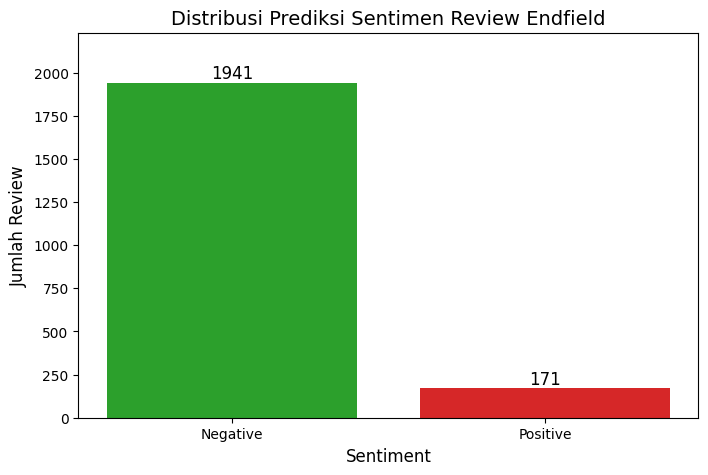

In [73]:

import matplotlib.pyplot as plt

# Hitung jumlah masing-masing sentimen
sentiment_counts = df_filtered_columns['sentiment_label'].value_counts()

# Membuat Bar Chart
plt.figure(figsize=(8, 5))
bars = plt.bar(sentiment_counts.index, sentiment_counts.values, color=['#2ca02c', '#d62728']) # Hijau & Merah

# Menambahkan judul dan label sumbu
plt.title('Distribusi Prediksi Sentimen Review Endfield', fontsize=14)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Jumlah Review', fontsize=12)

# Menambahkan angka (label) di atas setiap bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom', fontsize=12)

# Tampilkan grafik
plt.ylim(0, max(sentiment_counts.values) + max(sentiment_counts.values)*0.15) # Memberi ruang kosong di atas bar
plt.show()